In [ ]:
import os
import warnings
os.environ['PYTENSOR_FLAGS'] = 'mode=NUMBA'
warnings.filterwarnings("ignore", message="PyTensor could not link to a BLAS")
import pytensor
import numba
warnings.filterwarnings("ignore", category=numba.NumbaPerformanceWarning)
import numpy as np
import pandas as pd

import pymc as pm
import arviz as az

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-colorblind')
plt.rcParams['lines.linewidth'] = 2.5
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.linewidth'] = 1.2

In [2]:
df = pd.read_csv("./faithful.csv", index_col=0)
waiting_times = df["waiting"].values
df["standardized_waiting"] = (
    (waiting_times - waiting_times.mean()) 
    / waiting_times.std()
)
df

,eruptions,waiting,standardized_waiting
1,3.600,79,0.597123
2,1.800,54,-1.245181
3,3.333,74,0.228663
4,2.283,62,-0.655644
5,4.533,85,1.039277
...,...,...,...
268,4.117,81,0.744508
269,2.150,46,-1.834719
270,4.417,90,1.407737
271,1.817,46,-1.834719


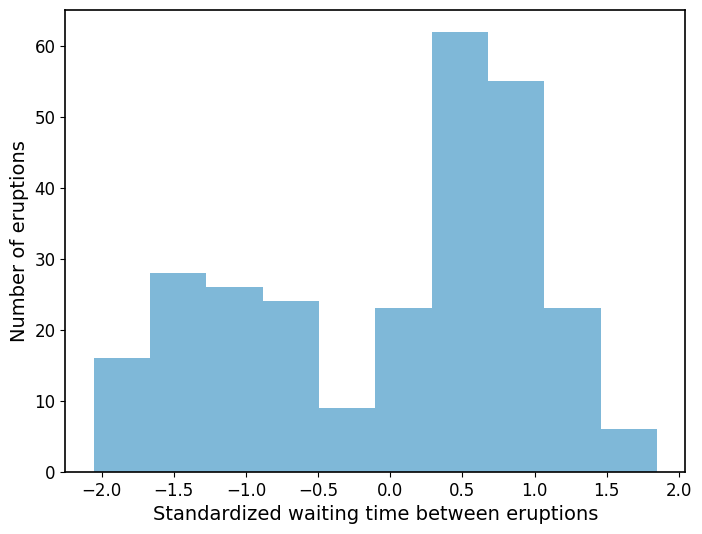

In [3]:
fig, ax = plt.subplots(figsize=(8, 6))

# n_bins = 20
ax.hist(df["standardized_waiting"], color="C0", lw=0, alpha=0.5)

ax.set_xlabel("Standardized waiting time between eruptions")
ax.set_ylabel("Number of eruptions")
plt.show()

In [4]:
with pm.Model(coords={"cluster": range(2)}) as model:
    mu = pm.Normal(
        "mu", 
        mu=0, 
        sigma=1,
        transform=pm.distributions.transforms.ordered,
        initval=[-1, 1],
        dims="cluster",
    )
    sigma = pm.HalfNormal("sigma", sigma=1, dims="cluster")
    w = pm.Dirichlet("w", np.ones(2), dims="cluster")
    obs = pm.NormalMixture(
        "obs", 
        w=w, 
        mu=mu, 
        sigma=sigma, 
        observed=df["standardized_waiting"].values,
    )

    samples = pm.sample(random_state=0)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, w]


Output()

Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 19 seconds.


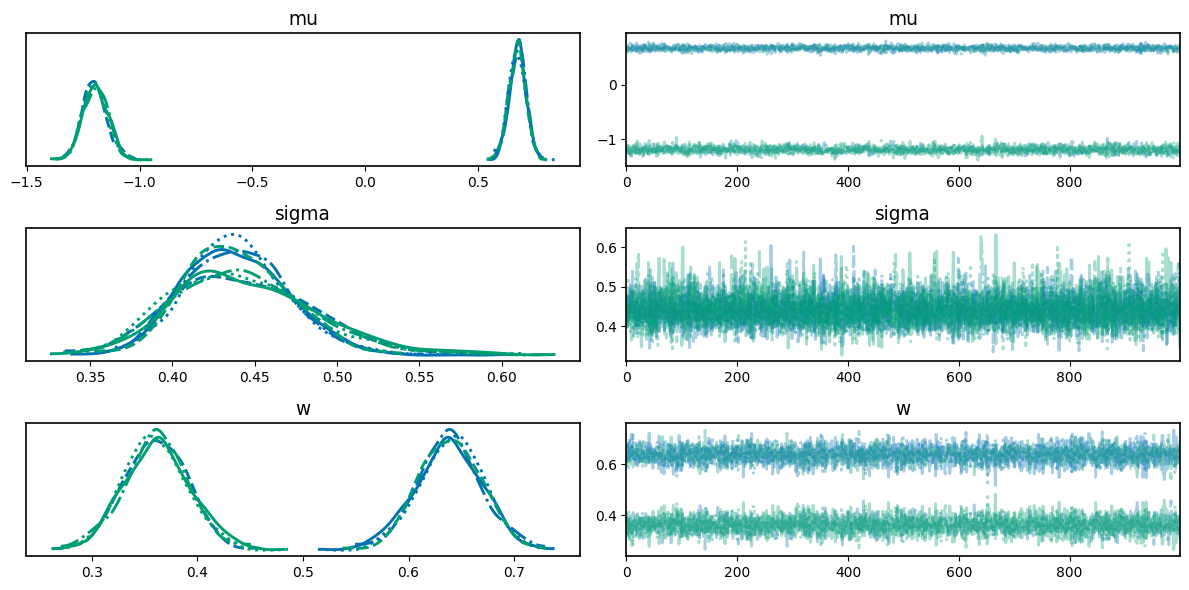

In [5]:
az.plot_trace(samples)
plt.tight_layout()
plt.show()

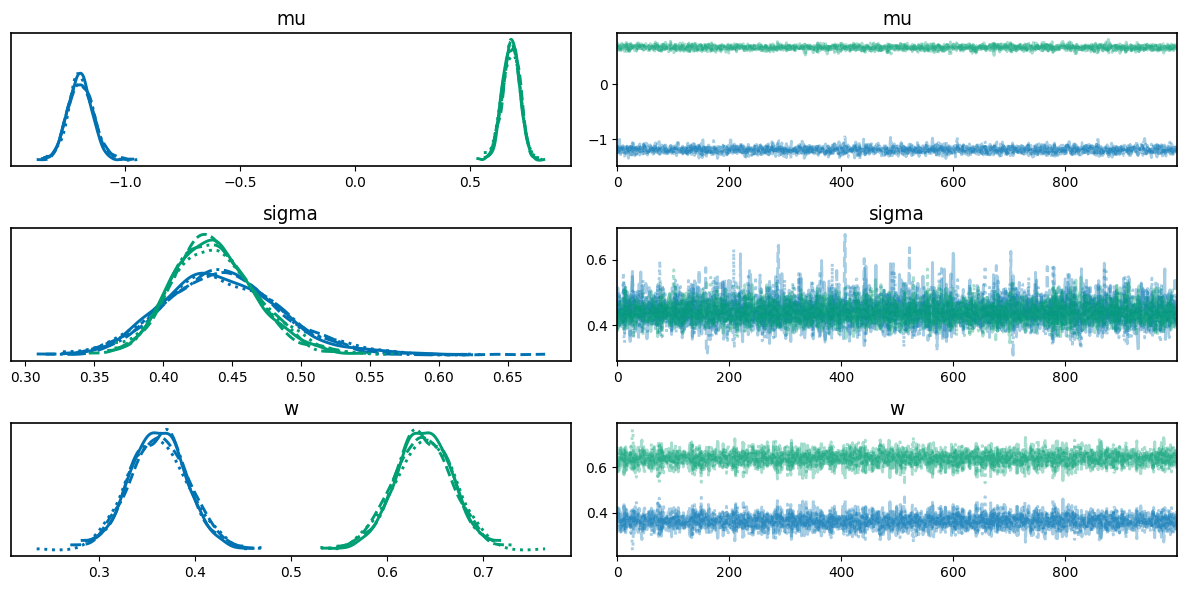

In [6]:
az.plot_trace(samples)
plt.tight_layout()
plt.show()

In [8]:
with model:
    ppc_samples = pm.sample_posterior_predictive(samples)

Sampling: [obs]


/Users/quannguyen/anaconda3/envs/gb/lib/python3.10/site-packages/rich/live.py:256: UserWarning: install 
"ipywidgets" for Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

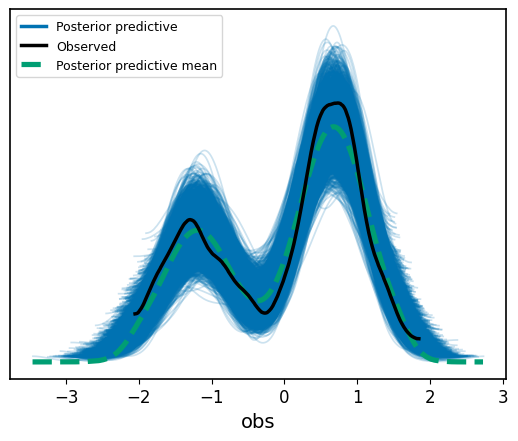

In [9]:
az.plot_ppc(ppc_samples)
plt.show()

In [5]:
from scipy.stats import norm
from xarray_einstats.stats import XrContinuousRV

In [6]:
xs = np.linspace(-2.5, 2.5, 101)
posterior = samples.posterior
pdf_components = (
    XrContinuousRV(norm, posterior["mu"], posterior["sigma"])
    .pdf(xs)
    * posterior["w"]
)
pdf = pdf_components.sum("cluster")

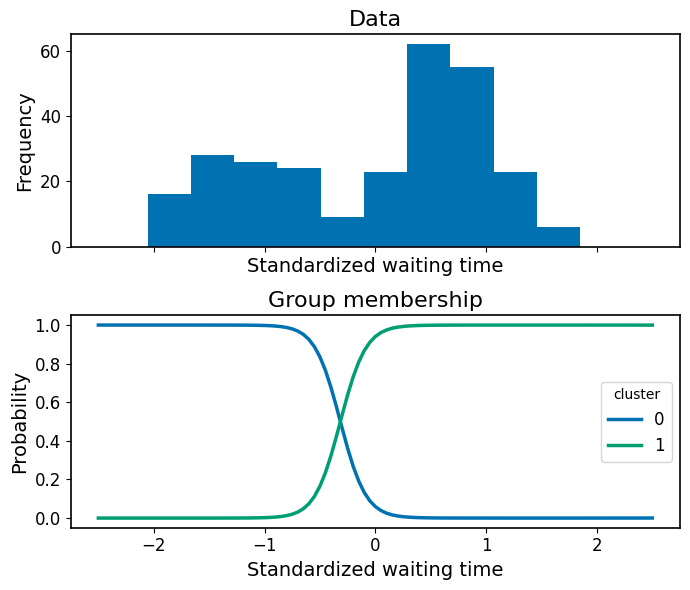

In [13]:
fig, ax = plt.subplots(2, 1, figsize=(7, 6), sharex=True)

# empirical histogram
ax[0].hist(df["standardized_waiting"])
ax[0].set(title="Data", xlabel="Standardized waiting time", ylabel="Frequency")

# # pdf
# pdf_components.mean(dim=["chain", "draw"]).sum("cluster").plot.line(ax=ax[1])
# ax[1].set(title="PDF", xlabel="Standardized waiting time", ylabel="Probability\ndensity")

# plot group membership probabilities
(pdf_components / pdf).mean(dim=["chain", "draw"]).plot.line(hue="cluster", ax=ax[1])
ax[1].set(title="Group membership", xlabel="Standardized waiting time", ylabel="Probability")

plt.tight_layout()
plt.show()

# Dirichlet process mixture

In [4]:
K = 10

In [5]:
def stick_breaking(beta):
    portion_remaining = pm.math.concatenate([[1], pm.math.cumprod(1 - beta)[:-1]])
    return beta * portion_remaining

In [ ]:
with pm.Model(coords={"cluster": np.arange(K)}) as dp_model:
    # Stick-breaking construction
    beta = pm.Beta("beta", alpha=1, beta=1, dims="cluster")
    w = pm.Deterministic("w", stick_breaking(beta), dims="cluster")
    
    # Component means and scales
    mu = pm.Normal(
        "mu", 
        mu=0, 
        sigma=1, 
        # initval=np.linspace(-1, 1, K).tolist(), 
        dims="cluster",
    )
    sigma = pm.HalfNormal("sigma", sigma=1, dims="cluster")
    
    # Mixture likelihood
    obs = pm.NormalMixture(
        "obs", 
        w=w, 
        mu=mu, 
        sigma=sigma, 
        observed=df["standardized_waiting"].values,
    )
    
    vi_approx = pm.fit(n=50_000)

Output()

In [ ]:
plt.plot(vi_approx.hist)
plt.show()

In [8]:
with dp_model:
    vi_samples = vi_approx.sample(1000, random_seed=0)

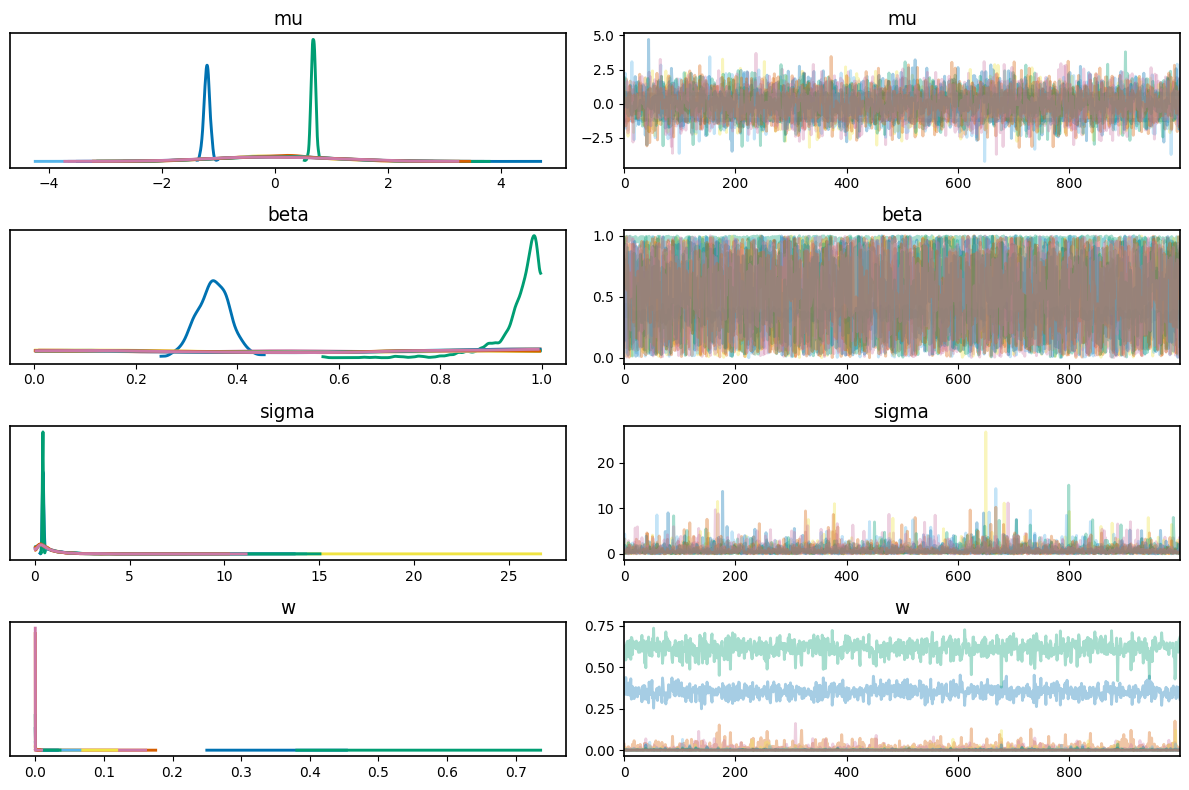

In [9]:
az.plot_trace(vi_samples)
plt.tight_layout()
plt.show()

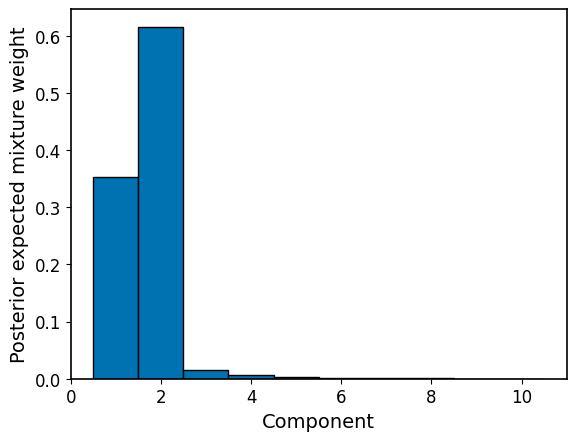

In [16]:
plot_w = np.arange(K) + 1

plt.bar(plot_w, vi_samples.posterior["w"].mean(("chain", "draw")), width=1.0, edgecolor="k")

# plt.xlim(0.5, K)
plt.xlabel("Component")

plt.ylabel("Posterior expected mixture weight")
plt.show()